# 🛰️ CloudSight: SAR → Optical Image Translation using CycleGAN
### Dataset: Sentinel-1 & 2 Image Pairs — SEN1-2 (Kaggle)
**Model:** CycleGAN with ResNet-6 Generator + PatchGAN Discriminator + SSIM Loss  
**Goal:** Translate cloud-penetrating SAR (Sentinel-1) images into human-interpretable optical (Sentinel-2) images  
**Platform:** Kaggle (P100 GPU)  
**Features:** Early stopping (patience=20), per-epoch checkpoints, best model tracking

> **Before running:** Go to `Settings → Accelerator → GPU P100` and enable **Internet ON**

## 1. Install Dependencies

In [1]:
!pip install torch==2.0.1+cu117 torchvision==0.15.2+cu117 --index-url https://download.pytorch.org/whl/cu117

Looking in indexes: https://download.pytorch.org/whl/cu117
ERROR: Could not find a version that satisfies the requirement torch==2.0.1+cu117 (from versions: none)
ERROR: No matching distribution found for torch==2.0.1+cu117


In [2]:
import torch
print(torch.__version__)          # should be 2.0.1+cu117
print(torch.cuda.is_available())  # should be True
print(torch.cuda.get_device_name(0))  # Tesla P100-PCIE-16GB
cap = torch.cuda.get_device_capability(0)
print(f'sm_{cap[0]}{cap[1]}')     # sm_60
print(torch.cuda.get_arch_list()) # should contain sm_60

2.10.0+cu128
True
Tesla T4
sm_75
['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [3]:
# scikit-image is pre-installed on Kaggle but we ensure latest version
# Internet must be ON in Kaggle settings for this to work
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

try:
    from skimage.metrics import structural_similarity
    print('scikit-image already available.')
except ImportError:
    install('scikit-image')
    print('scikit-image installed.')

print('All dependencies ready.')

scikit-image already available.
All dependencies ready.


## 2. Imports

In [4]:
import os
import glob
import random
import time
import itertools
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

from skimage.metrics import structural_similarity

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU detected. Training will be very slow on CPU.')

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 3. Configuration
**All hyperparameters and paths are here. Edit this cell only.**

In [5]:
class Config:
    # ── PATHS (Kaggle) ─────────────────────────────────────────────────────
    # /kaggle/input  → read-only dataset
    # /kaggle/working → writable; files here are saved after session ends
    DATA_ROOT      = '/kaggle/input/datasets/requiemonk/sentinel12-image-pairs-segregated-by-terrain/v_2'
    OUTPUT_DIR     = '/kaggle/working/outputs'
    CHECKPOINT_DIR = '/kaggle/working/checkpoints'
    WORKING_ROOT   = '/kaggle/working'   # ✅ Zips go here — visible in Output tab

    # ── DATASET ────────────────────────────────────────────────────────────
    # Two seasons → more terrain diversity (summer=green, spring=transitional)
    # Available: ROIs1158_spring | ROIs1868_summer | ROIs1970_fall | ROIs2017_winter
    ROI_FOLDERS       = ['agri', 'barrenland', 'grassland', 'urban']  # terrain classes under v_2/
    MAX_TRAIN_SAMPLES = 2000   # ~1500 per class (agri/barrenland/grassland/urban)
    MAX_VAL_SAMPLES   = 200    # ~150 per class

    # ── IMAGE ──────────────────────────────────────────────────────────────
    IMG_SIZE     = 256
    SAR_CHANNELS = 1    # Sentinel-1 → grayscale
    OPT_CHANNELS = 3    # Sentinel-2 → RGB

    # ── TRAINING ───────────────────────────────────────────────────────────
    EPOCHS     = 100
    BATCH_SIZE = 8      # Increased for 2x T4 GPUs (4 per GPU)
    LR         = 2e-4
    BETA1      = 0.5
    BETA2      = 0.999

    # ── EARLY STOPPING ─────────────────────────────────────────────────────
    PATIENCE = 20       # stop if val SSIM does not improve for 20 consecutive epochs

    # ── LOSS WEIGHTS ───────────────────────────────────────────────────────
    LAMBDA_CYC  = 10.0  # cycle consistency weight
    LAMBDA_ID   = 0.0   # identity loss weight (disabled due to channel mismatch)
    LAMBDA_SSIM = 2.0   # SSIM structural loss weight (our contribution)

    # ── GENERATOR ──────────────────────────────────────────────────────────
    N_RES_BLOCKS = 6    # ResNet blocks; 6 is optimal for 256×256 on P100
    NGF          = 64   # generator base channels
    NDF          = 64   # discriminator base channels

    # ── LR SCHEDULE ────────────────────────────────────────────────────────
    N_EPOCHS_DECAY = 50  # constant LR for epochs 1-50, linear decay 51-100

    # ── LOGGING & SAVING ───────────────────────────────────────────────────
    VIS_EVERY = 5       # visualize every N epochs
    SAVE_EVERY       = 5
    KEEP_LAST_N_CKPT = 3
    USE_AMP   = True    # mixed precision: ~30% faster, ~40% less VRAM on P100


cfg = Config()
os.makedirs(cfg.OUTPUT_DIR,     exist_ok=True)
os.makedirs(cfg.CHECKPOINT_DIR, exist_ok=True)

print('Config ready.')
print(f'  DATA_ROOT        : {cfg.DATA_ROOT}')
print(f'  OUTPUT_DIR       : {cfg.OUTPUT_DIR}')
print(f'  CHECKPOINT_DIR   : {cfg.CHECKPOINT_DIR}')
print(f'  Terrain classes  : {cfg.ROI_FOLDERS}')
print(f'  Train samples    : {cfg.MAX_TRAIN_SAMPLES}')
print(f'  Val samples      : {cfg.MAX_VAL_SAMPLES}')
print(f'  Epochs           : {cfg.EPOCHS}')
print(f'  Early stop pat.  : {cfg.PATIENCE}')
print(f'  Batch size       : {cfg.BATCH_SIZE}')
print(f'  Mixed precision  : {cfg.USE_AMP}')


Config ready.
  DATA_ROOT        : /kaggle/input/datasets/requiemonk/sentinel12-image-pairs-segregated-by-terrain/v_2
  OUTPUT_DIR       : /kaggle/working/outputs
  CHECKPOINT_DIR   : /kaggle/working/checkpoints
  Terrain classes  : ['agri', 'barrenland', 'grassland', 'urban']
  Train samples    : 2000
  Val samples      : 200
  Epochs           : 100
  Early stop pat.  : 20
  Batch size       : 4
  Mixed precision  : True


## 4. Dataset Discovery

In [6]:
# Verify dataset is mounted correctly
# On Kaggle: Add dataset via '+ Add Data' → search 'sentinel12-image-pairs-segregated-by-terrain'
print('Scanning dataset root...')
if os.path.exists(cfg.DATA_ROOT):
    entries = sorted(os.listdir(cfg.DATA_ROOT))
    print(f'Found {len(entries)} top-level entries:')
    for e in entries:
        full = os.path.join(cfg.DATA_ROOT, e)
        if os.path.isdir(full):
            n_sub = len(os.listdir(full))
            marker = ' ✅' if any(r in e for r in cfg.ROI_FOLDERS) else ''
            print(f'  📁 {e}/  ({n_sub} items){marker}')
else:
    print(f'❌ ERROR: Dataset not found at {cfg.DATA_ROOT}')
    print('   → Go to Kaggle notebook → Add Data → search:')
    print('     sentinel12-image-pairs-segregated-by-terrain')


Scanning dataset root...
Found 4 top-level entries:
  📁 agri/  (2 items) ✅
  📁 barrenland/  (2 items) ✅
  📁 grassland/  (2 items) ✅
  📁 urban/  (2 items) ✅


In [7]:
def find_image_pairs(data_root, terrain_classes):
    """
    Finds SAR / Optical image pairs from the v_2 dataset structure:

        data_root/
            agri/
                s1/   ← SAR  (Sentinel-1)
                s2/   ← Optical (Sentinel-2)
            barrenland/
                s1/
                s2/
            grassland/
                s1/
                s2/
            urban/
                s1/
                s2/

    Returns two parallel lists: sar_paths, opt_paths
    """
    sar_paths, opt_paths = [], []
    exts = ['*.png', '*.tif', '*.tiff', '*.jpg']

    def get_imgs(folder):
        imgs = []
        for ext in exts:
            imgs += sorted(glob.glob(os.path.join(folder, ext)))
        # Also scan one level deep (some datasets nest images in sub-folders)
        for ext in exts:
            imgs += sorted(glob.glob(os.path.join(folder, '**', ext), recursive=True))
        # Deduplicate while preserving order
        seen = set()
        result = []
        for p in imgs:
            if p not in seen:
                seen.add(p)
                result.append(p)
        return result

    for cls in terrain_classes:
        cls_path = os.path.join(data_root, cls)
        if not os.path.exists(cls_path):
            print(f'  WARNING: class folder not found → {cls_path}')
            continue

        s1_dir = os.path.join(cls_path, 's1')
        s2_dir = os.path.join(cls_path, 's2')

        if not os.path.exists(s1_dir):
            print(f'  WARNING: s1 folder missing in {cls}')
            continue
        if not os.path.exists(s2_dir):
            print(f'  WARNING: s2 folder missing in {cls}')
            continue

        s1_imgs = get_imgs(s1_dir)
        s2_imgs = get_imgs(s2_dir)
        n = min(len(s1_imgs), len(s2_imgs))

        if n == 0:
            print(f'  WARNING: no images found in {cls}/s1 or {cls}/s2')
            continue

        sar_paths.extend(s1_imgs[:n])
        opt_paths.extend(s2_imgs[:n])
        print(f'  {cls:12s} → {n} pairs  (s1: {len(s1_imgs)}, s2: {len(s2_imgs)})')

    return sar_paths, opt_paths


print('Scanning dataset...')
all_sar, all_opt = find_image_pairs(cfg.DATA_ROOT, cfg.ROI_FOLDERS)
print(f'\nTotal SAR images found    : {len(all_sar)}')
print(f'Total Optical images found: {len(all_opt)}')

assert len(all_sar) > 0, (
    'No images found!\n'
    f'Expected structure: {cfg.DATA_ROOT}/<class>/s1/ and s2/\n'
    f'Classes searched  : {cfg.ROI_FOLDERS}\n'
    'Check that DATA_ROOT points to the v_2 folder and the dataset is added to the notebook.'
)
assert len(all_sar) == len(all_opt), 'SAR and Optical counts do not match!'


Scanning dataset...
  agri         → 4000 pairs  (s1: 4000, s2: 4000)
  barrenland   → 4000 pairs  (s1: 4000, s2: 4000)
  grassland    → 4000 pairs  (s1: 4000, s2: 4000)
  urban        → 4000 pairs  (s1: 4000, s2: 4000)

Total SAR images found    : 16000
Total Optical images found: 16000


In [8]:
# Split into train / val
all_indices = list(range(len(all_sar)))
random.shuffle(all_indices)

train_n = min(cfg.MAX_TRAIN_SAMPLES, int(0.85 * len(all_indices)))
val_n   = min(cfg.MAX_VAL_SAMPLES,   len(all_indices) - train_n)

train_idx = all_indices[:train_n]
val_idx   = all_indices[train_n : train_n + val_n]

train_sar = [all_sar[i] for i in train_idx]
train_opt = [all_opt[i] for i in train_idx]
val_sar   = [all_sar[i] for i in val_idx]
val_opt   = [all_opt[i] for i in val_idx]

print(f'Train pairs : {len(train_sar)}')
print(f'Val pairs   : {len(val_sar)}')

Train pairs : 2000
Val pairs   : 200


## 5. Dataset & DataLoader

In [9]:
class SAROpticalDataset(Dataset):
    """
    Loads paired SAR (Sentinel-1) and Optical (Sentinel-2) image patches.
    In CycleGAN fashion, optical indices are shuffled during training
    to simulate an unpaired setting, while pairing is kept for evaluation.
    """
    def __init__(self, sar_paths, opt_paths, img_size=256, mode='train'):
        assert len(sar_paths) == len(opt_paths)
        self.sar_paths = sar_paths
        self.opt_paths = opt_paths
        self.img_size  = img_size
        self.mode      = mode

        # Shuffle optical index to simulate unpaired training
        self.opt_indices = list(range(len(opt_paths)))
        if mode == 'train':
            random.shuffle(self.opt_indices)

        # SAR transform: grayscale, normalize to [-1, 1]
        self.sar_transform = transforms.Compose([
            transforms.Resize((img_size, img_size),
                              interpolation=transforms.InterpolationMode.BICUBIC),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

        # Optical transform: RGB, normalize to [-1, 1]
        # Training gets random crop + flip for augmentation
        if mode == 'train':
            self.opt_transform = transforms.Compose([
                transforms.Resize((img_size + 30, img_size + 30),
                                  interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.RandomCrop(img_size),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            ])
        else:
            self.opt_transform = transforms.Compose([
                transforms.Resize((img_size, img_size),
                                  interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
            ])

    def _load_sar(self, path):
        img = Image.open(path)
        arr = np.array(img)
        # If multi-band tif, take first band
        if arr.ndim == 3:
            arr = arr[:, :, 0]
        # Percentile clip to remove radar outliers
        p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
        arr = np.clip(arr, p2, p98)
        if p98 > p2:
            arr = ((arr - p2) / (p98 - p2) * 255).astype(np.uint8)
        else:
            arr = np.zeros_like(arr, dtype=np.uint8)
        return Image.fromarray(arr, mode='L')

    def _load_optical(self, path):
        img = Image.open(path)
        return img.convert('RGB')

    def __len__(self):
        return len(self.sar_paths)

    def __getitem__(self, idx):
        sar_img = self._load_sar(self.sar_paths[idx])
        opt_img = self._load_optical(self.opt_paths[self.opt_indices[idx]])
        return self.sar_transform(sar_img), self.opt_transform(opt_img)


train_dataset = SAROpticalDataset(train_sar, train_opt, cfg.IMG_SIZE, mode='train')
val_dataset   = SAROpticalDataset(val_sar,   val_opt,   cfg.IMG_SIZE, mode='val')

train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                          shuffle=True,  num_workers=0, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=4,
                          shuffle=False, num_workers=0, pin_memory=True)

# Verify shapes
sar_b, opt_b = next(iter(train_loader))
print(f'SAR  batch : {sar_b.shape}  range [{sar_b.min():.2f}, {sar_b.max():.2f}]')
print(f'Opt  batch : {opt_b.shape} range [{opt_b.min():.2f}, {opt_b.max():.2f}]')
print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

/tmp/ipykernel_57/4041689070.py:60: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode='L')


SAR  batch : torch.Size([4, 1, 256, 256])  range [-1.00, 1.00]
Opt  batch : torch.Size([4, 3, 256, 256]) range [-1.00, 1.00]
Train batches : 500
Val batches   : 50


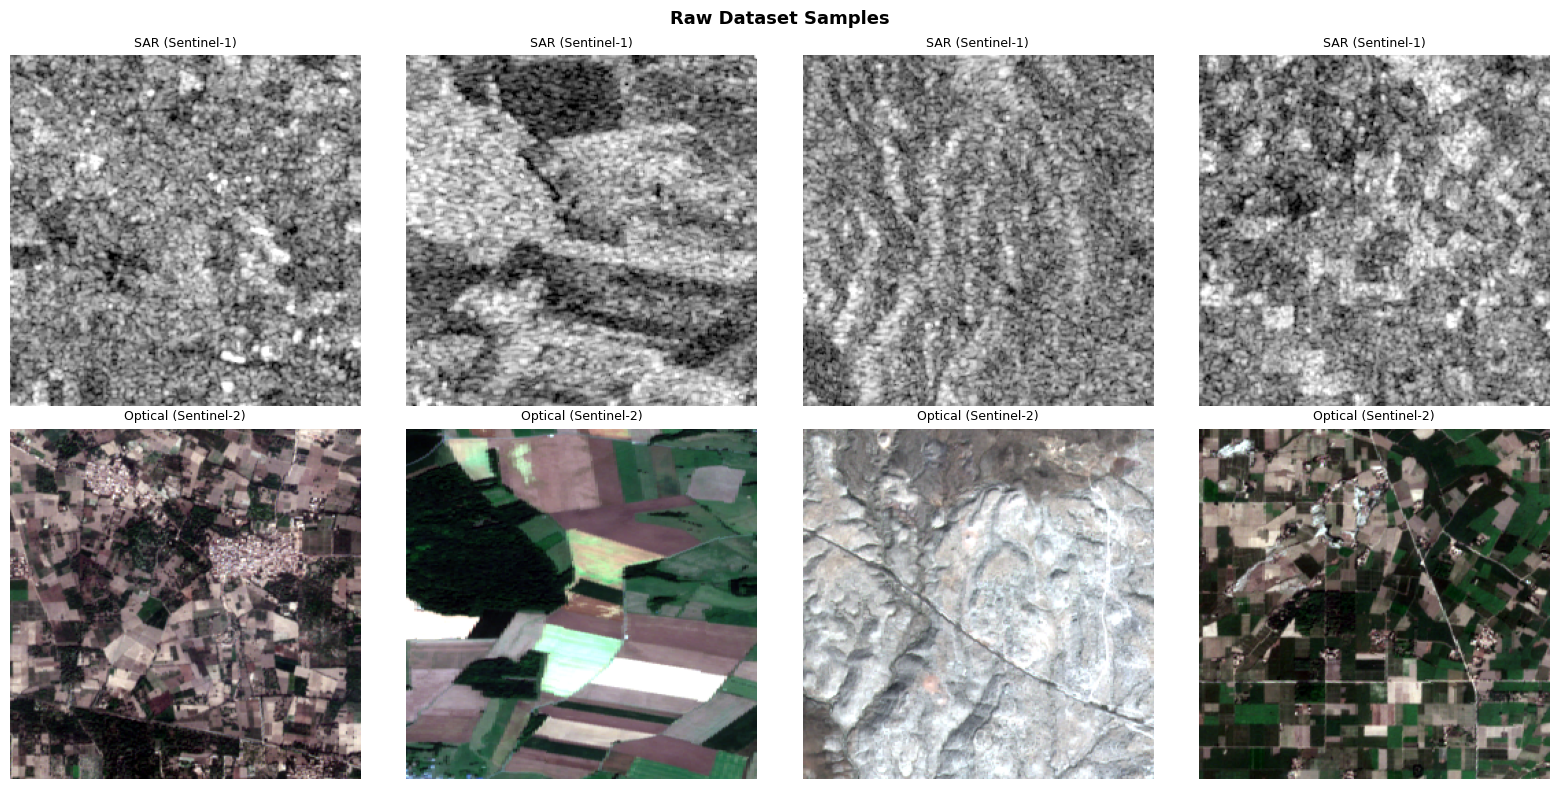

In [10]:
# Quick visual check of raw samples
def show_raw_samples(sar_paths, opt_paths, n=4):
    indices = random.sample(range(len(sar_paths)), min(n, len(sar_paths)))
    fig, axes = plt.subplots(2, n, figsize=(4*n, 8))
    for i, idx in enumerate(indices):
        sar_img = Image.open(sar_paths[idx])
        opt_img = Image.open(opt_paths[idx]).convert('RGB')
        axes[0, i].imshow(np.array(sar_img), cmap='gray')
        axes[0, i].set_title(f'SAR (Sentinel-1)', fontsize=9)
        axes[0, i].axis('off')
        axes[1, i].imshow(np.array(opt_img))
        axes[1, i].set_title(f'Optical (Sentinel-2)', fontsize=9)
        axes[1, i].axis('off')
    fig.suptitle('Raw Dataset Samples', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'raw_samples.png'), dpi=100, bbox_inches='tight')
    plt.show()

show_raw_samples(train_sar, train_opt)

## 6. Model Architecture

In [11]:
import torch, subprocess
print(torch.__version__)
print(torch.cuda.get_device_name(0))
cap = torch.cuda.get_device_capability(0)
print(f'sm_{cap[0]}{cap[1]}')
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)

2.10.0+cu128
Tesla T4
sm_75
Thu May  7 06:44:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   50C    P0             29W /   70W |     105MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-------------------

In [12]:
# ── RESIDUAL BLOCK ─────────────────────────────────────────────────────────
class ResidualBlock(nn.Module):
    """Core building block of the CycleGAN generator."""
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, bias=False),
            nn.InstanceNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(channels, channels, 3, bias=False),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, x):
        return x + self.block(x)


# ── GENERATOR ──────────────────────────────────────────────────────────────
class Generator(nn.Module):
    """
    ResNet-based encoder-decoder generator.
    G_AB: SAR (1ch) → Optical (3ch)
    G_BA: Optical (3ch) → SAR (1ch)
    """
    def __init__(self, in_channels, out_channels, ngf=64, n_res_blocks=6):
        super().__init__()
        layers = [
            # Encoder
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_channels, ngf, 7, bias=False),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True),

            nn.Conv2d(ngf,   ngf*2, 3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(ngf*2),
            nn.ReLU(inplace=True),

            nn.Conv2d(ngf*2, ngf*4, 3, stride=2, padding=1, bias=False),
            nn.InstanceNorm2d(ngf*4),
            nn.ReLU(inplace=True),
        ]

        # Transformer
        for _ in range(n_res_blocks):
            layers.append(ResidualBlock(ngf*4))

        layers += [
            # Decoder
            nn.ConvTranspose2d(ngf*4, ngf*2, 3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(ngf*2),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(ngf*2, ngf,   3, stride=2, padding=1, output_padding=1, bias=False),
            nn.InstanceNorm2d(ngf),
            nn.ReLU(inplace=True),

            nn.ReflectionPad2d(3),
            nn.Conv2d(ngf, out_channels, 7),
            nn.Tanh()  # output in [-1, 1]
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


# ── PATCHGAN DISCRIMINATOR ─────────────────────────────────────────────────
class PatchGANDiscriminator(nn.Module):
    """
    70x70 PatchGAN: classifies overlapping image patches as real/fake.
    More efficient than full-image discriminator; captures local texture.
    """
    def __init__(self, in_channels, ndf=64):
        super().__init__()

        def block(in_c, out_c, stride=2, normalize=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=stride, padding=1)]
            if normalize:
                layers.append(nn.InstanceNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_channels, ndf,   normalize=False),
            *block(ndf,         ndf*2),
            *block(ndf*2,       ndf*4),
            *block(ndf*4,       ndf*8, stride=1),
             nn.Conv2d(ndf*8, 1, 4, stride=1, padding=1)
        )

    def forward(self, x):
        return self.model(x)


# ── INSTANTIATE ────────────────────────────────────────────────────────────
G_AB = Generator(cfg.SAR_CHANNELS, cfg.OPT_CHANNELS, cfg.NGF, cfg.N_RES_BLOCKS).to(device)
G_BA = Generator(cfg.OPT_CHANNELS, cfg.SAR_CHANNELS, cfg.NGF, cfg.N_RES_BLOCKS).to(device)
D_A  = PatchGANDiscriminator(cfg.SAR_CHANNELS, cfg.NDF).to(device)
D_B  = PatchGANDiscriminator(cfg.OPT_CHANNELS, cfg.NDF).to(device)

if torch.cuda.device_count() > 1:
    print(f"Let's use {torch.cuda.device_count()} GPUs!")
    G_AB = nn.DataParallel(G_AB)
    G_BA = nn.DataParallel(G_BA)
    D_A = nn.DataParallel(D_A)
    D_B = nn.DataParallel(D_B)

# Weight init: N(0, 0.02)
def weights_init(m):
    cls = m.__class__.__name__
    if 'Conv' in cls:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'InstanceNorm2d' in cls:
        if m.weight is not None: nn.init.normal_(m.weight.data, 1.0, 0.02)
        if m.bias   is not None: nn.init.constant_(m.bias.data, 0.0)

for model in [G_AB, G_BA, D_A, D_B]:
    model.apply(weights_init)

def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(f'G_AB params : {count_params(G_AB)/1e6:.2f}M')
print(f'G_BA params : {count_params(G_BA)/1e6:.2f}M')
print(f'D_A  params : {count_params(D_A)/1e6:.2f}M')
print(f'D_B  params : {count_params(D_B)/1e6:.2f}M')
print(f'Total       : {(count_params(G_AB)+count_params(G_BA)+count_params(D_A)+count_params(D_B))/1e6:.2f}M')

G_AB params : 7.83M
G_BA params : 7.83M
D_A  params : 2.76M
D_B  params : 2.76M
Total       : 21.18M


## 7. Loss Functions & Utilities

In [13]:
# ── SSIM LOSS ──────────────────────────────────────────────────────────────
class SSIMLoss(nn.Module):
    """
    Structural Similarity Loss — our addition over vanilla CycleGAN.
    Penalizes structural differences between generated and real optical images.
    """
    def __init__(self, window_size=11, sigma=1.5):
        super().__init__()
        self.window_size = window_size
        self.sigma = sigma
        self.C1 = 0.01 ** 2
        self.C2 = 0.03 ** 2

    def _gaussian_kernel(self, channels, device):
        x = torch.arange(self.window_size, dtype=torch.float32, device=device) \
            - self.window_size // 2
        gauss = torch.exp(-x**2 / (2 * self.sigma**2))
        gauss = gauss / gauss.sum()
        k2d = gauss.unsqueeze(1) * gauss.unsqueeze(0)
        return k2d.unsqueeze(0).unsqueeze(0).repeat(channels, 1, 1, 1)

    def forward(self, x, y):
        ch  = x.size(1)
        pad = self.window_size // 2
        k   = self._gaussian_kernel(ch, x.device)

        mu_x  = F.conv2d(x,   k, padding=pad, groups=ch)
        mu_y  = F.conv2d(y,   k, padding=pad, groups=ch)
        mu_x2 = mu_x ** 2
        mu_y2 = mu_y ** 2
        mu_xy = mu_x * mu_y

        sig_x2 = F.conv2d(x*x, k, padding=pad, groups=ch) - mu_x2
        sig_y2 = F.conv2d(y*y, k, padding=pad, groups=ch) - mu_y2
        sig_xy = F.conv2d(x*y, k, padding=pad, groups=ch) - mu_xy

        num = (2*mu_xy + self.C1) * (2*sig_xy + self.C2)
        den = (mu_x2 + mu_y2 + self.C1) * (sig_x2 + sig_y2 + self.C2)
        return 1.0 - (num / (den + 1e-8)).mean()


# ── REPLAY BUFFER ──────────────────────────────────────────────────────────
class ReplayBuffer:
    """
    Stores previously generated images and randomly returns either
    a current or a past image to the discriminator.
    Reduces training oscillation (standard CycleGAN trick).
    """
    def __init__(self, max_size=50):
        self.max_size = max_size
        self.data = []

    def push_and_pop(self, data):
        result = []
        for el in data:
            el = el.unsqueeze(0)
            if len(self.data) < self.max_size:
                self.data.append(el)
                result.append(el)
            else:
                if random.random() > 0.5:
                    i = random.randint(0, self.max_size - 1)
                    result.append(self.data[i].clone())
                    self.data[i] = el
                else:
                    result.append(el)
        return torch.cat(result, dim=0)


criterion_GAN   = nn.MSELoss()     # LSGAN: more stable than BCE
criterion_cycle = nn.L1Loss()      # cycle consistency
criterion_id    = nn.L1Loss()      # identity
criterion_ssim  = SSIMLoss()       # structural (our addition)

fake_A_buffer = ReplayBuffer()
fake_B_buffer = ReplayBuffer()

print('Loss functions and buffers ready.')

Loss functions and buffers ready.


## 8. Optimizers & LR Schedulers

In [14]:
opt_G   = torch.optim.Adam(
    itertools.chain(G_AB.parameters(), G_BA.parameters()),
    lr=cfg.LR, betas=(cfg.BETA1, cfg.BETA2)
)
opt_D_A = torch.optim.Adam(D_A.parameters(), lr=cfg.LR, betas=(cfg.BETA1, cfg.BETA2))
opt_D_B = torch.optim.Adam(D_B.parameters(), lr=cfg.LR, betas=(cfg.BETA1, cfg.BETA2))

def lambda_lr(epoch):
    """Constant LR for first N_EPOCHS_DECAY, then linear decay to 0."""
    if epoch < cfg.N_EPOCHS_DECAY:
        return 1.0
    return max(0.0, 1.0 - (epoch - cfg.N_EPOCHS_DECAY) / (cfg.EPOCHS - cfg.N_EPOCHS_DECAY))

scheduler_G   = torch.optim.lr_scheduler.LambdaLR(opt_G,   lr_lambda=lambda_lr)
scheduler_D_A = torch.optim.lr_scheduler.LambdaLR(opt_D_A, lr_lambda=lambda_lr)
scheduler_D_B = torch.optim.lr_scheduler.LambdaLR(opt_D_B, lr_lambda=lambda_lr)

scaler = torch.cuda.amp.GradScaler(enabled=cfg.USE_AMP)

print('Optimizers ready.')

Optimizers ready.


/tmp/ipykernel_57/4044267982.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=cfg.USE_AMP)


## 9. Metric Helpers

In [15]:
def tensor_to_numpy(tensor):
    """Convert [-1,1] CHW tensor → [0,255] HWC uint8 numpy array."""
    img = tensor.detach().cpu()
    img = (img * 0.5 + 0.5).clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()
    return (img * 255).astype(np.uint8)


def compute_psnr(img1, img2):
    mse = np.mean((img1.astype(np.float64) - img2.astype(np.float64)) ** 2)
    return 100.0 if mse == 0 else 20 * np.log10(255.0 / np.sqrt(mse))


def compute_ssim(img1, img2):
    if img1.ndim == 3 and img1.shape[2] == 3:
        return structural_similarity(img1, img2, channel_axis=2, data_range=255)
    return structural_similarity(img1.squeeze(), img2.squeeze(), data_range=255)


@torch.no_grad()
def evaluate(G_AB, val_loader, device):
    G_AB.eval()
    psnr_list, ssim_list = [], []
    for sar, opt_real in val_loader:
        sar      = sar.to(device)
        opt_real = opt_real.to(device)
        with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
            opt_fake = G_AB(sar)
        for i in range(opt_real.size(0)):
            real_np = tensor_to_numpy(opt_real[i])
            fake_np = tensor_to_numpy(opt_fake[i])
            psnr_list.append(compute_psnr(real_np, fake_np))
            ssim_list.append(compute_ssim(real_np, fake_np))
    G_AB.train()
    return float(np.mean(psnr_list)), float(np.mean(ssim_list))


print('Metric helpers ready.')

Metric helpers ready.


## 10. Visualization Helper

In [16]:
@torch.no_grad()
def visualize_results(G_AB, G_BA, val_loader, epoch, psnr=None, ssim_val=None):
    G_AB.eval(); G_BA.eval()

    sar_b, opt_b = next(iter(val_loader))
    sar_b = sar_b[:4].to(device)
    opt_b = opt_b[:4].to(device)

    with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
        fake_opt = G_AB(sar_b)
        fake_sar = G_BA(opt_b)
        rec_sar  = G_BA(fake_opt)
        rec_opt  = G_AB(fake_sar)

    def to_rgb_list(t):
        imgs = []
        for i in range(t.size(0)):
            arr = tensor_to_numpy(t[i])
            if arr.ndim == 2:
                arr = np.stack([arr]*3, axis=-1)
            elif arr.shape[2] == 1:
                arr = np.concatenate([arr]*3, axis=-1)
            imgs.append(arr)
        return imgs

    rows = [
        ('SAR Input (A)',              to_rgb_list(sar_b)),
        ('Generated Optical (A→B)',    to_rgb_list(fake_opt)),
        ('Real Optical (B)',           to_rgb_list(opt_b)),
        ('Reconstructed SAR (A→B→A)', to_rgb_list(rec_sar)),
    ]

    n = len(rows[0][1])
    fig, axes = plt.subplots(4, n, figsize=(4*n, 16))

    metric_str = ''
    if psnr is not None:
        metric_str = f' | PSNR: {psnr:.2f} dB  SSIM: {ssim_val:.4f}'
    fig.suptitle(f'Epoch {epoch}{metric_str}', fontsize=13, fontweight='bold')

    for row_i, (label, imgs) in enumerate(rows):
        for col_i, img in enumerate(imgs):
            ax = axes[row_i, col_i]
            ax.imshow(img)
            ax.axis('off')
            if col_i == 0:
                ax.set_ylabel(label, fontsize=10, fontweight='bold')

    plt.tight_layout()
    path = os.path.join(cfg.OUTPUT_DIR, f'results_epoch_{epoch:04d}.png')
    plt.savefig(path, dpi=100, bbox_inches='tight')
    # plt.show()
    plt.close(fig)

    G_AB.train(); G_BA.train()


print('Visualization helper ready.')

Visualization helper ready.


## 11. Checkpoint Helpers

In [17]:
import zipfile as _zipfile, glob as _glob

def _unwrap(m):
    return m.module if hasattr(m, 'module') else m

def save_checkpoint(epoch, is_best=False, extra=None):
    """
    Saves last checkpoint and best checkpoint.
    Prevents Kaggle from running out of disk space!
    """
    def get_state_dict(model):
        return model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
        
    ckpt = {
        'epoch'  : epoch,
        'G_AB'   : get_state_dict(G_AB),
        'G_BA'   : get_state_dict(G_BA),
        'D_A'    : get_state_dict(D_A),
        'D_B'    : get_state_dict(D_B),
        'opt_G'  : opt_G.state_dict(),
        'opt_D_A': opt_D_A.state_dict(),
        'opt_D_B': opt_D_B.state_dict(),
        'history': dict(history),
    }
    if extra:
        ckpt.update(extra)

    # ONLY SAVE LAST MODEL INSTEAD OF EVERY EPOCH (Saves space!)
    epoch_path = os.path.join(cfg.CHECKPOINT_DIR, 'last_model.pth')
    torch.save(ckpt, epoch_path)

    if is_best:
        best_path = os.path.join(cfg.CHECKPOINT_DIR, 'best_model.pth')
        torch.save(ckpt, best_path)
        print(f'  ★ BEST model saved  (epoch {epoch})')

def load_best_model():
    best_path = os.path.join(cfg.CHECKPOINT_DIR, 'best_model.pth')
    if os.path.exists(best_path):
        ckpt = torch.load(best_path, map_location=device)
        if isinstance(G_AB, nn.DataParallel):
            G_AB.module.load_state_dict(ckpt['G_AB'])
            G_BA.module.load_state_dict(ckpt['G_BA'])
        else:
            G_AB.load_state_dict(ckpt['G_AB'])
            G_BA.load_state_dict(ckpt['G_BA'])
        print(f'Best model loaded from epoch {ckpt["epoch"]}')
        return ckpt
    else:
        print('No best_model.pth found. Using current weights.')
        return None
    ckpt = torch.load(path, map_location=device)
    _unwrap(G_AB).load_state_dict(ckpt['G_AB'])
    _unwrap(G_BA).load_state_dict(ckpt['G_BA'])
    print(f'✅ Loaded checkpoint from epoch {ckpt["epoch"]}  [{path}]')
    return ckpt

load_best_model = load_checkpoint
print('Checkpoint helpers ready.')


Checkpoint helpers ready.


## 12. Training Loop (with Early Stopping)

In [23]:
def train_one_epoch(epoch):
    G_AB.train(); G_BA.train(); D_A.train(); D_B.train()
    losses = defaultdict(float)
    t0 = time.time()

    # Pre-compute patch label shape (done once per epoch)
    with torch.no_grad():
        dummy = torch.zeros(1, cfg.SAR_CHANNELS, cfg.IMG_SIZE, cfg.IMG_SIZE, device=device)
        patch_shape = D_A(dummy).shape

    real_label = torch.ones(patch_shape,  device=device)
    fake_label = torch.zeros(patch_shape, device=device)

    for i, (real_A, real_B) in enumerate(train_loader):
        real_A = real_A.to(device, non_blocking=True)  # SAR
        real_B = real_B.to(device, non_blocking=True)  # Optical

        bs = real_A.size(0)
        rl = real_label.expand(bs, *patch_shape[1:])
        fl = fake_label.expand(bs, *patch_shape[1:])

        # ── GENERATOR ─────────────────────────────────────────────────────
        opt_G.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
            fake_B = G_AB(real_A)       # SAR → Optical
            fake_A = G_BA(real_B)       # Optical → SAR
            rec_A  = G_BA(fake_B)       # SAR → Optical → SAR
            rec_B  = G_AB(fake_A)       # Optical → SAR → Optical
            # id_A   = G_BA(real_A)       # SAR identity
            # id_B   = G_AB(real_B)       # Optical identity
            # # AFTER
            # id_A   = G_AB(real_A)       # SAR identity
            # id_B   = G_BA(real_B)       # Optical identity

            loss_adv  = criterion_GAN(D_B(fake_B), rl) + criterion_GAN(D_A(fake_A), rl)
            loss_cyc  = (criterion_cycle(rec_A, real_A) + criterion_cycle(rec_B, real_B)) * cfg.LAMBDA_CYC
            # loss_id   = (criterion_id(id_A, real_A)     + criterion_id(id_B, real_B))     * cfg.LAMBDA_ID
            # loss_id = criterion_id(id_B, real_B) * cfg.LAMBDA_ID
            loss_ssim = criterion_ssim(fake_B, real_B) * cfg.LAMBDA_SSIM
            # loss_G    = loss_adv + loss_cyc + loss_id + loss_ssim
            loss_G = loss_adv + loss_cyc + loss_ssim
        scaler.scale(loss_G).backward()
        scaler.step(opt_G)

        # ── DISCRIMINATOR A (SAR) ─────────────────────────────────────────
        opt_D_A.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
            fake_A_buf = fake_A_buffer.push_and_pop(fake_A.detach())
            loss_D_A   = (criterion_GAN(D_A(real_A),     rl) +
                          criterion_GAN(D_A(fake_A_buf), fl)) * 0.5
        scaler.scale(loss_D_A).backward()
        scaler.step(opt_D_A)

        # ── DISCRIMINATOR B (Optical) ─────────────────────────────────────
        opt_D_B.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
            fake_B_buf = fake_B_buffer.push_and_pop(fake_B.detach())
            loss_D_B   = (criterion_GAN(D_B(real_B),     rl) +
                          criterion_GAN(D_B(fake_B_buf), fl)) * 0.5
        scaler.scale(loss_D_B).backward()
        scaler.step(opt_D_B)

        scaler.update()

        losses['G_total'] += loss_G.item()
        losses['G_adv']   += loss_adv.item()
        losses['G_cyc']   += loss_cyc.item()
        # losses['G_id']    += loss_id.item()
        losses['G_ssim']  += loss_ssim.item()
        losses['D_A']     += loss_D_A.item()
        losses['D_B']     += loss_D_B.item()

        if (i + 1) % 100 == 0:
            print(f'  [{epoch}/{cfg.EPOCHS}] batch {i+1}/{len(train_loader)} '
                  f'G:{loss_G.item():.3f} '
                  f'D_A:{loss_D_A.item():.3f} '
                  f'D_B:{loss_D_B.item():.3f} '
                  f'SSIM_loss:{loss_ssim.item():.3f} '
                  f'[{time.time()-t0:.0f}s]')

    nb = len(train_loader)
    return {k: v/nb for k, v in losses.items()}

In [ ]:
# ── MAIN TRAINING LOOP ─────────────────────────────────────────────────────
history     = defaultdict(list)
best_ssim   = -1.0
best_epoch  = -1
patience_ctr = 0
stopped_early = False

print(f'Starting training')
print(f'  Epochs       : {cfg.EPOCHS}')
print(f'  Patience     : {cfg.PATIENCE} epochs')
print(f'  Train batches: {len(train_loader)}')
print(f'  Device       : {device} | AMP: {cfg.USE_AMP}')
print('='*70)

for epoch in range(1, cfg.EPOCHS + 1):
    t_start = time.time()

    # Train one epoch
    losses = train_one_epoch(epoch)

    # Step LR schedulers
    scheduler_G.step()
    scheduler_D_A.step()
    scheduler_D_B.step()

    # Log losses
    for k, v in losses.items():
        history[k].append(v)

    # Evaluate every epoch
    psnr, ssim_val = evaluate(G_AB, val_loader, device)
    history['val_psnr'].append(psnr)
    history['val_ssim'].append(ssim_val)

    elapsed = time.time() - t_start
    lr_now  = scheduler_G.get_last_lr()[0]

    # Determine if this is the best epoch
    is_best = ssim_val > best_ssim
    if is_best:
        best_ssim  = ssim_val
        best_epoch = epoch
        patience_ctr = 0
    else:
        patience_ctr += 1

    # Print epoch summary
    best_marker = ' ★ BEST' if is_best else ''
    print(f'Epoch [{epoch:4d}/{cfg.EPOCHS}] '
          f'G:{losses["G_total"]:.3f} '
          f'cyc:{losses["G_cyc"]:.3f} '
          f'ssim:{losses["G_ssim"]:.3f} '
          f'D_A:{losses["D_A"]:.3f} '
          f'D_B:{losses["D_B"]:.3f} '
          f'| PSNR:{psnr:.2f} SSIM:{ssim_val:.4f} '
          f'| pat:{patience_ctr}/{cfg.PATIENCE} '
          f'| LR:{lr_now:.5f} '
          f'| {elapsed:.0f}s'
          f'{best_marker}')

    # Save checkpoint every epoch (+ mark best)
    save_checkpoint(epoch, is_best=is_best, extra={'val_psnr': psnr, 'val_ssim': ssim_val})

    # Visualize every VIS_EVERY epochs
    if epoch % cfg.VIS_EVERY == 0 or epoch == 1:
        visualize_results(G_AB, G_BA, val_loader, epoch, psnr=psnr, ssim_val=ssim_val)

    # Early stopping check
    if patience_ctr >= cfg.PATIENCE:
        print('='*70)
        print(f'EARLY STOPPING triggered at epoch {epoch}')
        print(f'Val SSIM did not improve for {cfg.PATIENCE} consecutive epochs.')
        print(f'Best epoch: {best_epoch} | Best SSIM: {best_ssim:.4f}')
        stopped_early = True
        break

    print('-'*70)

print('='*70)
if not stopped_early:
    print('Training complete — all epochs finished.')
print(f'Best epoch : {best_epoch}  |  Best Val SSIM : {best_ssim:.4f}')

Starting training
  Epochs       : 100
  Patience     : 20 epochs
  Train batches: 500
  Device       : cuda | AMP: True


/tmp/ipykernel_57/4041689070.py:60: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(arr, mode='L')
/tmp/ipykernel_57/1688459862.py:24: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
/tmp/ipykernel_57/1688459862.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
/tmp/ipykernel_57/1688459862.py:56: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):


  [1/100] batch 100/500 G:7.855 D_A:0.272 D_B:0.296 SSIM_loss:1.916 [52s]
  [1/100] batch 200/500 G:6.941 D_A:0.221 D_B:0.343 SSIM_loss:1.937 [107s]
  [1/100] batch 300/500 G:6.641 D_A:0.292 D_B:0.229 SSIM_loss:1.925 [162s]
  [1/100] batch 400/500 G:6.610 D_A:0.246 D_B:0.224 SSIM_loss:1.923 [217s]
  [1/100] batch 500/500 G:6.245 D_A:0.225 D_B:0.201 SSIM_loss:1.938 [272s]


/tmp/ipykernel_57/1465117897.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):


Epoch [   1/100] G:7.721 cyc:4.858 ssim:1.923 D_A:0.351 D_B:0.359 | PSNR:11.06 SSIM:0.0475 | pat:0/20 | LR:0.00020 | 283s ★ BEST
  ★ best_model.zip (232.4 MB) — epoch 1


/tmp/ipykernel_57/96642452.py:9: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):


----------------------------------------------------------------------
  [2/100] batch 100/500 G:6.373 D_A:0.195 D_B:0.176 SSIM_loss:1.923 [50s]
  [2/100] batch 200/500 G:6.677 D_A:0.236 D_B:0.164 SSIM_loss:1.903 [98s]
  [2/100] batch 300/500 G:7.324 D_A:0.188 D_B:0.316 SSIM_loss:1.934 [148s]
  [2/100] batch 400/500 G:5.876 D_A:0.192 D_B:0.165 SSIM_loss:1.894 [197s]
  [2/100] batch 500/500 G:5.601 D_A:0.204 D_B:0.209 SSIM_loss:1.849 [246s]
Epoch [   2/100] G:6.638 cyc:3.909 ssim:1.922 D_A:0.226 D_B:0.297 | PSNR:11.44 SSIM:0.0694 | pat:0/20 | LR:0.00020 | 254s ★ BEST
  ★ best_model.zip (232.4 MB) — epoch 2
----------------------------------------------------------------------
  [3/100] batch 100/500 G:6.335 D_A:0.246 D_B:0.232 SSIM_loss:1.872 [50s]
  [3/100] batch 200/500 G:7.663 D_A:0.225 D_B:0.246 SSIM_loss:1.896 [98s]
  [3/100] batch 300/500 G:5.977 D_A:0.220 D_B:0.233 SSIM_loss:1.929 [147s]
  [3/100] batch 400/500 G:5.036 D_A:0.213 D_B:0.213 SSIM_loss:1.931 [195s]
  [3/100] batch 50

## 13. Training Curves

In [ ]:
def plot_training_curves(history, best_epoch):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('CloudSight — CycleGAN Training Curves', fontsize=15, fontweight='bold')

    loss_keys = [
        ('G_total', 'Generator Total Loss',       'tab:blue'),
        ('G_adv',   'Adversarial Loss',           'tab:orange'),
        ('G_cyc',   'Cycle Consistency Loss',     'tab:green'),
        ('G_ssim',  'SSIM Loss (Our Addition)',   'tab:red'),
        ('D_A',     'Discriminator A Loss (SAR)', 'tab:purple'),
        ('D_B',     'Discriminator B Loss (Opt)', 'tab:brown'),
    ]

    for ax, (key, title, color) in zip(axes.flatten(), loss_keys):
        if key not in history:
            continue
        vals = history[key]
        ax.plot(vals, color=color, linewidth=1.2, alpha=0.6, label='per epoch')
        if len(vals) > 5:
            smooth = np.convolve(vals, np.ones(5)/5, mode='valid')
            ax.plot(range(4, len(vals)), smooth, color=color, linewidth=2.2, label='smoothed')
        ax.axvline(best_epoch - 1, color='gold', linewidth=1.5, linestyle='--', label=f'best (ep {best_epoch})')
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'training_curves.png'), dpi=120, bbox_inches='tight')
    plt.show()


def plot_val_metrics(history, best_epoch):
    psnr_vals = history.get('val_psnr', [])
    ssim_vals = history.get('val_ssim', [])
    if not psnr_vals:
        return
    epochs = list(range(1, len(psnr_vals) + 1))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Validation Metrics per Epoch', fontsize=13, fontweight='bold')

    ax1.plot(epochs, psnr_vals, 'o-', color='tab:blue', linewidth=2, markersize=3)
    ax1.axvline(best_epoch, color='gold', linestyle='--', linewidth=1.5, label=f'best (ep {best_epoch})')
    ax1.set_title('PSNR (dB) — Higher is Better')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('PSNR (dB)')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, ssim_vals, 'o-', color='tab:green', linewidth=2, markersize=3)
    ax2.axvline(best_epoch, color='gold', linestyle='--', linewidth=1.5, label=f'best (ep {best_epoch})')
    ax2.set_title('SSIM — Higher is Better')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('SSIM')
    ax2.legend(); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'val_metrics.png'), dpi=120, bbox_inches='tight')
    plt.show()


plot_training_curves(dict(history), best_epoch)
plot_val_metrics(dict(history), best_epoch)

## 14. Final Evaluation (Best Model)

In [ ]:
# Load best model checkpoint
load_best_model()

In [ ]:
@torch.no_grad()
def final_evaluation(G_AB, val_loader, device):
    G_AB.eval()
    all_psnr, all_ssim = [], []

    for sar, opt_real in val_loader:
        sar      = sar.to(device)
        opt_real = opt_real.to(device)
        with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
            opt_fake = G_AB(sar)
        for i in range(opt_real.size(0)):
            real_np = tensor_to_numpy(opt_real[i])
            fake_np = tensor_to_numpy(opt_fake[i])
            all_psnr.append(compute_psnr(real_np, fake_np))
            all_ssim.append(compute_ssim(real_np, fake_np))

    return {
        'PSNR mean': np.mean(all_psnr),
        'PSNR std':  np.std(all_psnr),
        'SSIM mean': np.mean(all_ssim),
        'SSIM std':  np.std(all_ssim),
        'Samples':   len(all_psnr)
    }, all_psnr, all_ssim


results, all_psnr, all_ssim = final_evaluation(G_AB, val_loader, device)

print('='*50)
print('FINAL EVALUATION (Best Model)')
print('='*50)
for k, v in results.items():
    print(f'  {k:15s}: {v:.4f}')
print('='*50)

In [ ]:
# Metric distribution plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Metric Distributions — Validation Set (Best Model)', fontsize=13, fontweight='bold')

ax1.hist(all_psnr, bins=30, color='tab:blue', alpha=0.8, edgecolor='black')
ax1.axvline(np.mean(all_psnr), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(all_psnr):.2f} dB')
ax1.set_title('PSNR Distribution'); ax1.set_xlabel('PSNR (dB)'); ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.hist(all_ssim, bins=30, color='tab:green', alpha=0.8, edgecolor='black')
ax2.axvline(np.mean(all_ssim), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(all_ssim):.4f}')
ax2.set_title('SSIM Distribution'); ax2.set_xlabel('SSIM'); ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(cfg.OUTPUT_DIR, 'metric_distributions.png'), dpi=120, bbox_inches='tight')
plt.show()

## 15. Final Results Grid

In [ ]:
@torch.no_grad()
def final_results_grid(G_AB, val_loader, device, n=8):
    G_AB.eval()
    all_sar_imgs, all_fake_opt, all_real_opt = [], [], []

    for sar, opt_real in val_loader:
        sar      = sar.to(device)
        opt_real = opt_real.to(device)
        with torch.cuda.amp.autocast(enabled=cfg.USE_AMP):
            fake_opt = G_AB(sar)
        for i in range(sar.size(0)):
            arr = tensor_to_numpy(sar[i])
            if arr.ndim == 2 or arr.shape[2] == 1:
                arr = np.concatenate([arr.reshape(cfg.IMG_SIZE, cfg.IMG_SIZE, 1)]*3, axis=-1)
            all_sar_imgs.append(arr)
            all_fake_opt.append(tensor_to_numpy(fake_opt[i]))
            all_real_opt.append(tensor_to_numpy(opt_real[i]))
        if len(all_sar_imgs) >= n:
            break

    n = min(n, len(all_sar_imgs))
    fig, axes = plt.subplots(3, n, figsize=(2.8*n, 9.5))
    fig.patch.set_facecolor('#111111')

    rows = [
        ('SAR Input (Sentinel-1)',    all_sar_imgs),
        ('Generated Optical (Ours)', all_fake_opt),
        ('Real Optical (Sentinel-2)', all_real_opt),
    ]

    for ri, (label, imgs) in enumerate(rows):
        for ci in range(n):
            ax = axes[ri, ci]
            ax.imshow(imgs[ci])
            ax.axis('off')
            ax.set_facecolor('#111111')
            if ci == 0:
                ax.set_ylabel(label, color='white', fontsize=10, fontweight='bold', labelpad=10)
                ax.yaxis.label.set_visible(True)

    fig.suptitle(
        f'CloudSight: SAR → Optical Translation\n'
        f'Best Epoch: {best_epoch}  |  PSNR: {results["PSNR mean"]:.2f} dB  |  SSIM: {results["SSIM mean"]:.4f}',
        fontsize=13, fontweight='bold', color='white'
    )
    plt.tight_layout()
    out_path = os.path.join(cfg.OUTPUT_DIR, 'final_results_grid.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#111111')
    plt.show()
    print(f'Saved → {out_path}')


final_results_grid(G_AB, val_loader, device, n=8)

## 16. Summary

In [ ]:
actual_epochs = len(history['val_ssim'])

print('\n' + '='*60)
print('  CLOUDSIGHT — PROJECT SUMMARY')
print('='*60)
print(f'  Task          : SAR → Optical Image Translation')
print(f'  Model         : CycleGAN + SSIM Loss')
print(f'  Dataset       : SEN1-2 (Sentinel-1 & 2, Kaggle)')
print(f'  ROI Folders   : {", ".join(cfg.ROI_FOLDERS)}')
print(f'  Train pairs   : {len(train_sar)}')
print(f'  Val pairs     : {len(val_sar)}')
print(f'  Max Epochs    : {cfg.EPOCHS}')
print(f'  Actual Epochs : {actual_epochs} ({"early stopped" if stopped_early else "completed"})')
print(f'  Best Epoch    : {best_epoch}')
print(f'  Patience      : {cfg.PATIENCE}')
print(f'  Image Size    : {cfg.IMG_SIZE}×{cfg.IMG_SIZE}')
print(f'  Generator     : ResNet-{cfg.N_RES_BLOCKS} | {count_params(G_AB)/1e6:.2f}M params')
print(f'  Discriminator : PatchGAN 70×70 | {count_params(D_A)/1e6:.2f}M params')
print(f'  Loss          : Adversarial + Cycle (λ={cfg.LAMBDA_CYC}) + Identity (λ={cfg.LAMBDA_ID}) + SSIM (λ={cfg.LAMBDA_SSIM})')
print('-'*60)
print(f'  FINAL METRICS (Best Model, Val Set)')
print(f'  PSNR : {results["PSNR mean"]:.2f} ± {results["PSNR std"]:.2f} dB')
print(f'  SSIM : {results["SSIM mean"]:.4f} ± {results["SSIM std"]:.4f}')
print('='*60)
print('  Output files:')
for f in sorted(os.listdir(cfg.OUTPUT_DIR)):
    fpath = os.path.join(cfg.OUTPUT_DIR, f)
    size  = os.path.getsize(fpath) / 1024
    print(f'    {f}  ({size:.1f} KB)')
print('='*60)